In this post I want to go through a simplified simulation and some mathematics revolving around handling exposures in insurance data, particularly in the GLM case because it makes things easier.

In [103]:
import numpy as np
from sklearn.linear_model import GammaRegressor
import matplotlib.pyplot as plt
import cvxpy as cp

rng = np.random.default_rng()

First, the data generating process. Here we assume a Poisson distribution for claim counts and an independent Log-Normal distribution for claim amounts. We assume that the average number of claims is proportional to exposure and we add a random risk multiplier term to give some idiosyncratic variance to each observation:

In [ ]:
n = 50_000
exposure = rng.integers(1, 1000, n)

mu = 1
var = 0.1
risk_mult = rng.gamma(shape=mu**2 / var, scale=var / mu, size=n)

base_freq = 0.1  # Expected number of claims per unit of exposure at risk = 1
sev_mu = 5.0  # Log-normal severity: mean/sd of the underlying normal (log scale)
sev_sigma = 1.0

claim_counts = rng.poisson(base_freq * exposure * risk_mult)
losses = np.array([rng.lognormal(sev_mu, sev_sigma, k).sum() for k in claim_counts])

Mathematically, our data generating process is this:

$$
\begin{align*}
C &\sim \text{Poisson}(\lambda) \\
X &\sim \text{LogNormal}(\mu, \sigma^2) \\
L &= \sum_{i=1}^{C} X
\end{align*}
$$

Following some basic results about compound Poisson random variables we have:
$$
\begin{align*}
\text{E}[L] &= \lambda \exp \left( \mu + \frac{\sigma^2}{2} \right) \\
\text{Var}(L) &= \lambda \text{E}[X^2] = \lambda \exp(2 \mu + 2 \sigma^2)
\end{align*}
$$

Text(0.5, 1.0, 'Risk Multiplier Distribution')

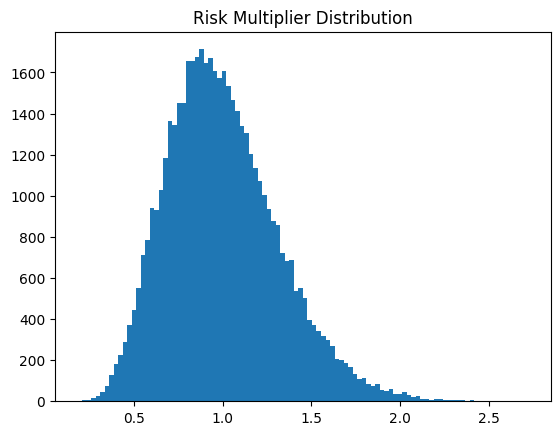

In [118]:
plt.hist(risk_mult, bins=100)
plt.title("Risk Multiplier Distribution")

Text(0.5, 1.0, 'Total Loss Amount Distribution')

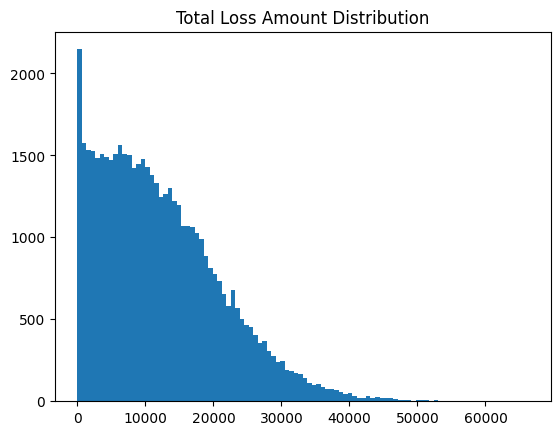

In [120]:
plt.hist(losses, bins=100)
plt.title("Total Loss Amount Distribution")

A very typical actuarial analysis will instead use pure premium instead of straight losses. Pure premium is defined as the total loss divided by the exposure:

Text(0.5, 1.0, 'Pure Premium Distribution')

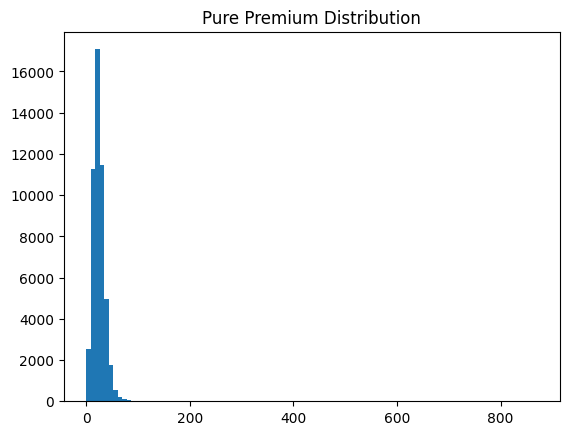

In [121]:
pure_prem = losses / exposure
plt.hist(pure_prem, bins=100)
plt.title("Pure Premium Distribution")

Given that exposures are known constants, from basic probability rules we get:

$$
\begin{align*}
\text{Pure Premium} &= \frac{L}{\text{Exposure}} \\
\text{E}[\text{Pure Premium}] &= \frac{\text{E}[L]}{\text{Exposure}} \\
\text{Var}(\text{Pure Premium}) &= \frac{\text{Var}(L)}{\text{Exposure}^2}
\end{align*}
$$

The last equation there being the most critical: by dividing by exposure we make the variance of pure premium ratios depend non-linearly on the exposure values. From the above equation for the variance of total losses, we see, because $\lambda$ is proportional to exposure, that we expect variance to increase as exposure increases, which we can see easily:

Text(0, 0.5, 'Total Loss')

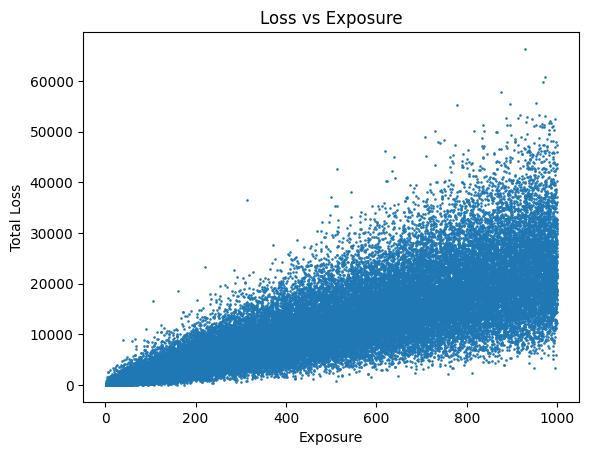

In [122]:
plt.scatter(exposure, losses, s=0.75)
plt.title("Loss vs Exposure")
plt.xlabel("Exposure")
plt.ylabel("Total Loss")

If we instead plot *pure premium* versus exposure, you can see how this relationship inverts (taking log values so large and small values become more comparable):

Text(0, 0.5, 'Pure Premium (log)')

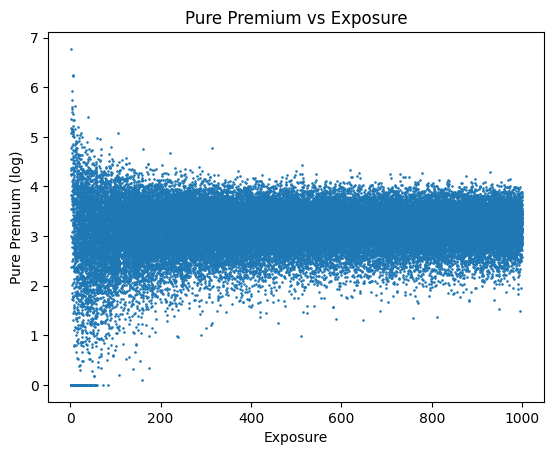

In [124]:
plt.scatter(exposure, np.log(1 + pure_prem), s=0.75)
plt.title("Pure Premium vs Exposure")
plt.xlabel("Exposure")
plt.ylabel("Pure Premium (log)")

Now, small policies have the widest spread in pure premium values. This can bite: I have made the mistake of clipping these ratios at some quantile value instead of losses to handle outliers. This creates a structural bias because small policies are most likely to have extreme pure premium values. Advice: don't do this.

In [112]:
# TODO: Extend this simple data generating process to a severity distribution with power law tails
# and show the practical effects of that on a modeling process. Especially: how much do we lose if we
# assume we can accurately model claim counts and use a constant mean estimate for claim severity?

In [113]:
# TODO: Does creating some kind of latent implied exposure make any sense?

Now, if we want to model losses we want to embed this prior knowledge about exposures into the model. There are two ways of doing this. First, we model losses directly and insert exposure as an *offset*. Second, we can model pure premium instead, where we must then insert exposure as a *weight*.

## Offset Method

The first method is introducing exposure as an offset. If we a priori assume that claims are proportional to exposure, and we use a log-link, then we can add a constant term to our linear predictor (the bit inside the link function) that is the natural log of exposure. Here, we assume there are no exogenous predictors so we have simply:

$$
\begin{align*}
\mu &= \exp(\alpha + \ln(\text{Exposure})) \\
&= \exp(\alpha) * \text{Exposure}
\end{align*}
$$

This way, the "modeled" part of losses is just a multiplier on exposure, in this case this will be a constant parameter. Using the Poisson likelihood we can fit this:

In [114]:
alpha = cp.Variable()

eta = alpha + np.log(exposure)
log_likelihood = claim_counts @ eta - cp.sum(cp.exp(eta))

prob = cp.Problem(cp.Maximize(log_likelihood))
prob.solve()

print(f"Intercept (alpha): {np.exp(alpha.value):.4f}")

Intercept (alpha): 0.1002


And we recover the base frequency value we set at the start. Note that the average risk multiplier given by the Gamma distribution is 1, so it cancels out in aggregate.

## Weight Method

The other way to achieve this is by modeling frequency instead, which is claim counts divided by exposure. We then model these ratios with a Poisson likelihood with a sample weight equal to the exposure.

Even though the Poisson distribution is only supported on integers, this is a quasi-likelihood approach. As long as the mean function is correctly specified, this will still give consistent mean estimates. Because frequency is just a rescaling of claim counts, the mean function is unaffected so this works. Note that there are extra details about the over-dispersion aspect of the model. Because the risk multipliers are Gamma-distributed, we introduce more variance into the resulting claim counts than the Poisson distribution would generally indicate. If what we care about is estimating the mean frequency, this does not matter because it doesn't influence the mean function. However, if we want to get standard errors and other variance-related estimates correct, we would need to estimate a dispersion parameter to adjust for this, but I will ignore that here for simplicity.

We can solve the same kind of problem as in the offset case, but this time exposure comes in as a weight:

In [115]:
frequency = claim_counts / exposure

alpha_freq = cp.Variable()  # intercept-only: constant frequency across all policies
weighted_log_likelihood = exposure @ (frequency * alpha_freq - cp.exp(alpha_freq))

prob_freq = cp.Problem(cp.Maximize(weighted_log_likelihood))
prob_freq.solve()

print(f"Fitted constant frequency exp(b0): {np.exp(alpha_freq.value):.4f}")

Fitted constant frequency exp(b0): 0.1002


And we again recover the same base frequency value.

From the Poisson log-likelihood we can derive a nice result because of the simplicity of the model here. First, we can show that $\alpha$ must be equal to a weighted average of our observed frequencies (claim count divided by exposure, denoted $k$):

The Poisson log-likelihood is: $\ell = k \ln(\lambda) - \lambda - \ln(k!)$ Then we can show:

$$
\begin{align*}
&\text{Assume:} \quad \lambda = \exp(\alpha) \\
&\text{Then:} \quad k \ln(\lambda) - \lambda = k \alpha - \exp(\alpha) \\
&\text{So:} \quad \ell(\alpha) = \sum_i w_i (k_i \alpha - \exp(\alpha))
\end{align*}
$$


From the log-likelihood, the solution must obey the first order condition:
$$
\begin{align*}
\frac{\partial \ell}{\partial \alpha} = 0 \quad &\Rightarrow \quad \sum_i w_i (k_i - \exp(\alpha)) = 0 \\
&\Rightarrow \exp(\alpha) = \frac{\sum_i w_i k_i}{\sum_i w_i}
\end{align*}
$$

If we assume that weights are all 1, the unweighted case, we have:
$$
\exp(\alpha) = \frac{1}{n} \sum_i k_i
$$
which is just the sample average of frequency values. However, if we use weights equal to exposure, $E_i$, and knowing that frequency $k_i = \frac{C_i}{E_i}$ we get:
$$
\exp(\alpha) = \frac{\sum_i E_i \frac{C_i}{E_i}}{\sum_i E_i} = \frac{\sum_i C_i}{\sum_i E_i}
$$
which is the total observed frequency: total claims divided by total exposure. In this case, because we assume that base frequency, 0.1 claims per exposure, is constant, and the average risk multiplier is 1, the average frequency of each policy and the overall frequency are the same. This will not be true in a general case. This matches actuarial intuition: the frequency of a book of policies is not the average of each policy's frequency, but the total claim count divided by the total exposure.

## Equivalence Conditions

Note that this exact equivalence between the exposure-as-offset and exposure-as-weight here is only because the Poisson distribution has the mean-variance relationship it does, namely that the mean and variance are both equal to $\lambda$. In other cases, technically any Tweedie distribution with power not equal to 1, this does not hold. For the below I will move to the pure premium case because that is usually more natural for the Tweedie distribution in applications.

Assume that $\eta_i = \sum_j \beta_j x_j$ is the linear predictor given a set of variables $x_j$, and that $\mu_i = \exp(\eta_i)$, in other words assume a log-link. Then, from the likelihood of a generic exponential dispersion distribution you can show that the score function (derivative of the log-likelihood) for a given linear predictor parameter is:
$$
\frac{\partial \ell}{\partial \beta_j} = \sum_i w_i \frac{y_i - \mu_i}{V(\mu_i)} \frac{\partial \mu_i}{\partial \eta_i} x_{ij}
$$

Let $m_i = \exp(\sum_j \beta_j x_j)$ for convenience. There are then two cases, the loss outcome with exposure offset case, and the frequency outcome with exposure weight case. In the loss outcome case you have $\eta_i = \ln(E_i) + \sum_j \beta_j x_j$ so $\mu_i = E_i m_i$, and note that $y_i = L_i$. In the frequency case you have $\eta_i = \sum_j \beta_j x_j$ so $\mu_i = m_i$, and $y_i = \frac{L_i}{E_i}$

Thus, for the offset case, where all $w_i = 1$:
$$
\frac{\partial \ell}{\partial \beta_j} = \sum_i \frac{L_i - E_i m_i}{V(E_i m_i)} E_i m_i x_{ij}
$$

If we assume the general Tweedie variance function: $V(\mu) = \mu^p$ then we get:
$$
= \sum_i \frac{L_i - E_i m_i}{E_i^p V(m_i)} E_i m_i x_{ij} = \sum_i \frac{E_i^2}{E_i^p} \frac{\frac{L_i}{E_i} - m_i}{V(m_i)} m_i x_{ij}
$$

You can already see that we've rearranged this to get frequency in the numerator, so starting again for the frequency case where we have non-one weights:
$$
\frac{\partial \ell}{\partial \beta_j} = \sum_i w_i \frac{\frac{L_i}{E_i} - m_i}{V(m_i)} m_i x_{ij}
$$

So, for the score functions to be equal, and thus to arrive at the same estimated coefficients, we need:
$$
w_i = \frac{E_i^2}{E_i^p} = E_i^{2-p}
$$

In the Poisson case we have $V(\mu) = \mu$ and thus $p=1$, which recovers the case above where the weights are simply equal to the exposures. However, in every other case, to achieve equivalence you need to set the weights to be a power transformation of the exposures.

This has important implications for cases where you are using non-Poisson distributions. Especially in the common case where you are modeling pure premium instead of frequencies. Then, your objective is total loss divided by exposure. The Tweedie distribution is typically used here with $1 \lt p \lt 2$. In this case, modeling losses and setting exposure as an offset is making a different claim than modeling pure premium and setting exposure as a weight (at least without modifying the exposure values according to the above equation).

In the offset case, you are making a claim about how losses scale with exposure, namely that they do so linearly. In the weight case you are only saying that pure premium ratios have variance that is inversely proportional to exposure. If you believe that exposures are non-linearly related to losses, then using exposures as weights still makes sense because it is merely adjusting for non-constant variance, which is induced purely by taking the ratio to begin with. Using exposure as an offset, however, is embedding that linearity assumption into the model itself, which may or may not make sense based on your assumptions.

# Conclusion

Dealing with exposures in insurance modeling problems is a unique issue that I had never thought through enough, and, as usual, working through the math makes things much clearer. Essentially it comes down to the fact that you need to stick exposure somewhere, and you can do it through an offset or by modeling a ratio directly. In the latter case you need to use sample weights both for efficiency's sake and to recover the offset solution. The simple Poisson model on frequency makes this equivalence quite nice. In the case I've constructed here where there are no exogenous predictors, the frequency model turns into an intercept-only one and you can clearly see how the unweighted and weighted solutions differ, with the weighted version simplifying into the total observed frequency, which is the typical actuarial solution.

One big note is how you have to transform the exposure in the sample weighted case if you're using a Tweedie distribution. In order to have it match the offset solution, and in fact to make it the most efficient, you need to put exposure to the power of $2-p$. When doing weighted regressions you need the weights to be inversely proportional to the variance of each observation, and in this case if you miss that non-linear transformation that won't hold.